In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('data/car_price_prediction.csv')
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [36]:
data.shape

(19237, 18)

In [37]:
data.isna().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [38]:
data.duplicated().sum()

np.int64(313)

In [39]:
data.drop_duplicates(inplace=True)

In [40]:
data.shape

(18924, 18)

In [41]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.892400e+04,1.892400e+04,18924.000000,18924.000000,18924.000000
mean,4.557538e+07,1.858744e+04,2010.914236,4.580216,6.568379
std,9.375468e+05,1.921356e+05,5.665749,1.200223,4.322323
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569501e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577191e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580174e+07,2.206300e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [42]:
data.select_dtypes(include=['object']).describe()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5709,3729,1069,8600,13731,9944,3856,714,13282,12695,18032,17471,4944


In [ ]:
def top_and_bottom_combined(df, col ,n=5):
    top_counts = df[col].value_counts().head(n)
    bottom_counts = df[col].value_counts().tail(n)

    combined = pd.concat([top_counts, bottom_counts], axis=0)
    combined.columns = ["Most Frequent", "Least Frequent"]
    return combined

for col in data.select_dtypes(include = 'object'):
    print(f"{col} value counts:")
    print(top_and_bottom_combined(data, col))
    print("30 Unique values:", data[col].unique()[:30])
    print("-------------------------------")
    

Levy value counts:
Levy
-       5709
765      482
891      453
639      403
640      398
3156       1
2908       1
1279       1
1719       1
1901       1
Name: count, dtype: int64
30 Unique values: ['1399' '1018' '-' '862' '446' '891' '761' '751' '394' '1053' '1055'
 '1079' '810' '2386' '1850' '531' '586' '1249' '2455' '583' '1537' '1288'
 '915' '1750' '707' '1077' '1486' '1091' '650' '382']
-------------------------------
Manufacturer value counts:
Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
TESLA               1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, dtype: int64
30 Unique values: ['LEXUS' 'CHEVROLET' 'HONDA' 'FORD' 'HYUNDAI' 'TOYOTA' 'MERCEDES-BENZ'
 'OPEL' 'PORSCHE' 'BMW' 'JEEP' 'VOLKSWAGEN' 'AUDI' 'RENAULT' 'NISSAN'
 'SUBARU' 'DAEWOO' 'KIA' 'MITSUBISHI' 'SSANGYONG' 'MAZDA' 'GMC' 'FIAT'
 'INFINITI' 'ALFA ROMEO' 'SUZUKI' 'ACURA' 'LINCOLN' 'VAZ'

In [44]:
data["Levy"].replace({"-" : 0}, inplace=True)
data["Levy"] = pd.to_numeric(data["Levy"])


In [45]:
data["Levy"]

0        1399
1        1018
2           0
3         862
4         446
         ... 
19232       0
19233     831
19234     836
19235    1288
19236     753
Name: Levy, Length: 18924, dtype: int64

In [46]:
data["Engine volume"] = data["Engine volume"].str.replace("Turbo", "")
data["Engine volume"] = pd.to_numeric(data["Engine volume"])

In [47]:
data["Engine volume"]

0        3.5
1        3.0
2        1.3
3        2.5
4        1.3
        ... 
19232    2.0
19233    2.4
19234    2.0
19235    2.0
19236    2.4
Name: Engine volume, Length: 18924, dtype: float64

In [48]:
data["Mileage"] = data["Mileage"].str.replace("km", "")
data["Mileage"] = pd.to_numeric(data["Mileage"])

In [50]:
data.drop(["Doors"], axis=1, inplace=True)

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  int64  
 3   Manufacturer      18924 non-null  object 
 4   Model             18924 non-null  object 
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  object 
 7   Leather interior  18924 non-null  object 
 8   Fuel type         18924 non-null  object 
 9   Engine volume     18924 non-null  float64
 10  Mileage           18924 non-null  int64  
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  object 
 13  Drive wheels      18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

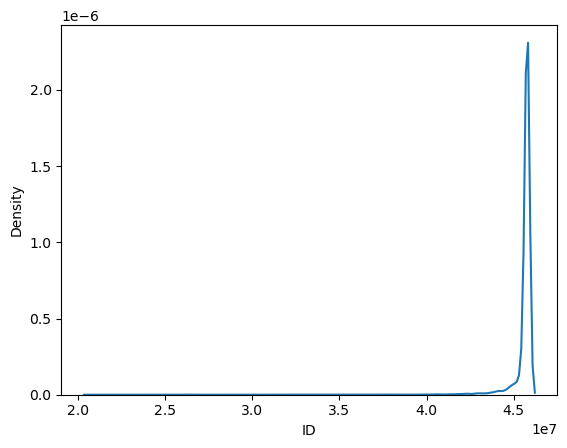

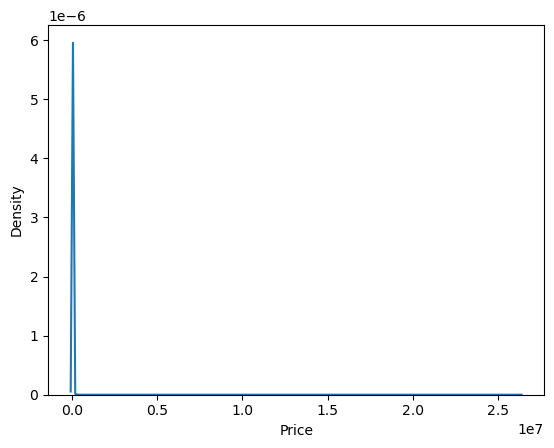

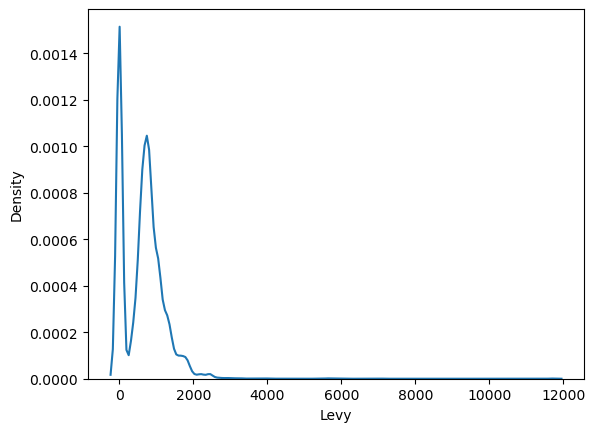

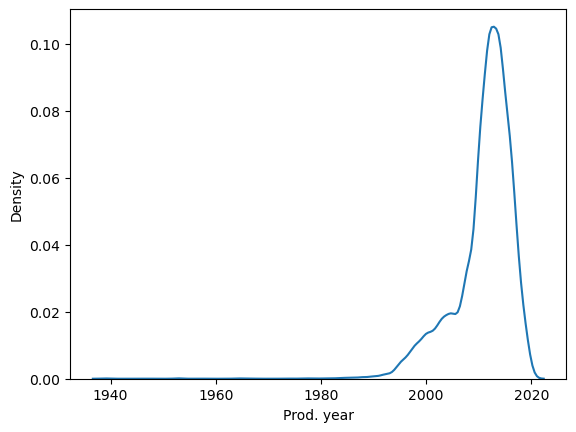

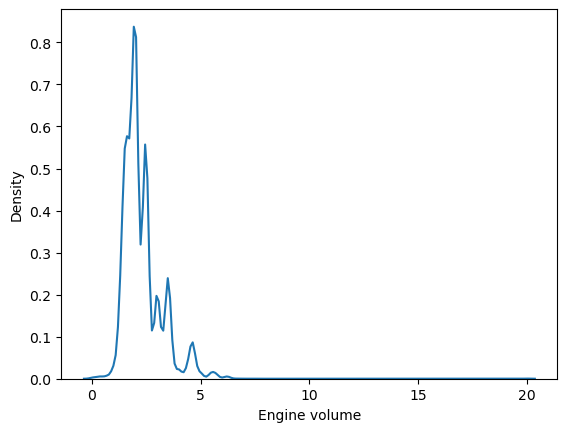

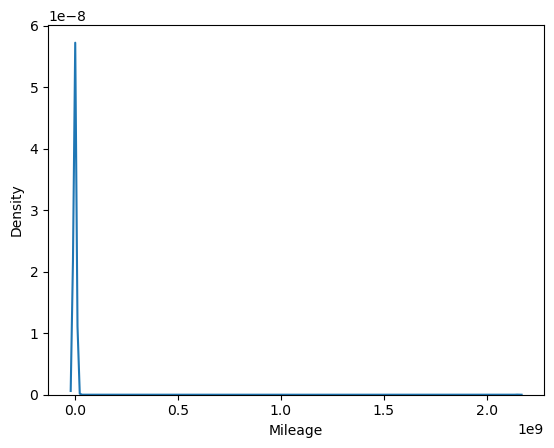

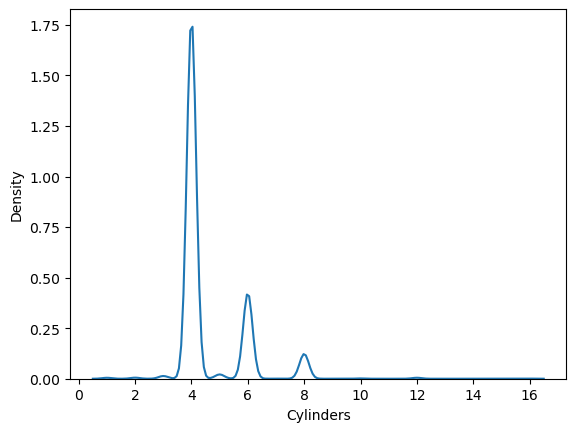

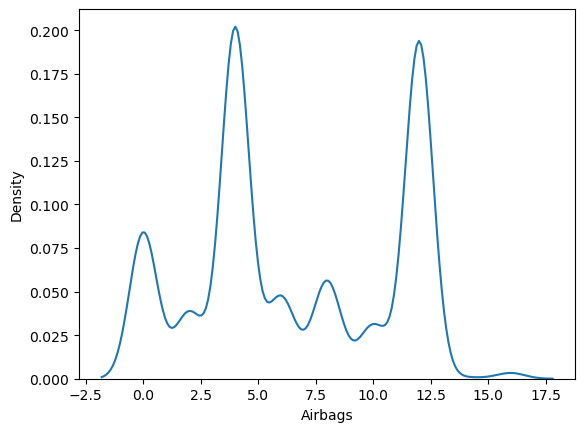

In [52]:
for col in data.select_dtypes('number').columns:
    sns.kdeplot(data[col])
    plt.show()

c:\Users\w.i\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Mileage', ylabel='Density'>

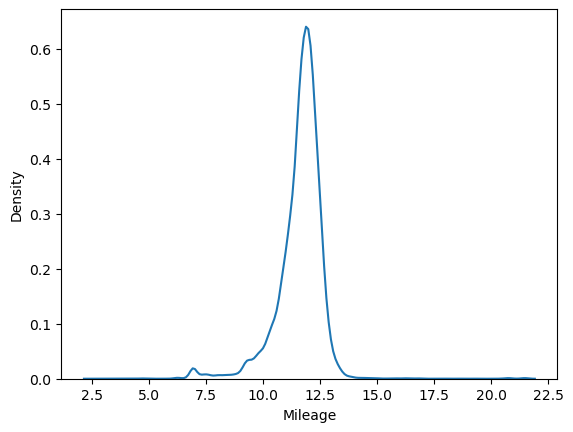

In [53]:
sns.kdeplot(np.log(data["Mileage"]))

In [ ]:
# Correlation (numeric only = True )
data.corr(numeric_only=True)

,ID,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
ID,1.000000,-0.000797,0.103477,0.072030,-0.013155,0.004225,-0.040617,-0.022070
Price,-0.000797,1.000000,-0.003558,0.012689,0.008888,-0.001763,0.007435,-0.012709
Levy,0.103477,-0.003558,1.000000,0.362827,0.378117,-0.021203,0.251632,0.125015
Prod. year,0.072030,0.012689,0.362827,1.000000,-0.032427,-0.064058,-0.099443,0.235160
Engine volume,-0.013155,0.008888,0.378117,-0.032427,1.000000,-0.006292,0.777228,0.221991
Mileage,0.004225,-0.001763,-0.021203,-0.064058,-0.006292,1.000000,-0.001720,-0.009174
Cylinders,-0.040617,0.007435,0.251632,-0.099443,0.777228,-0.001720,1.000000,0.174112
Airbags,-0.022070,-0.012709,0.125015,0.235160,0.221991,-0.009174,0.174112,1.000000


<Axes: >

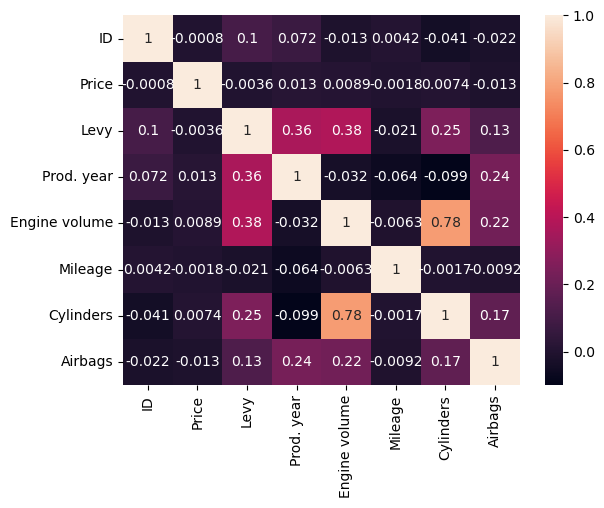

In [56]:
sns.heatmap(data.corr(numeric_only=True), annot=True)

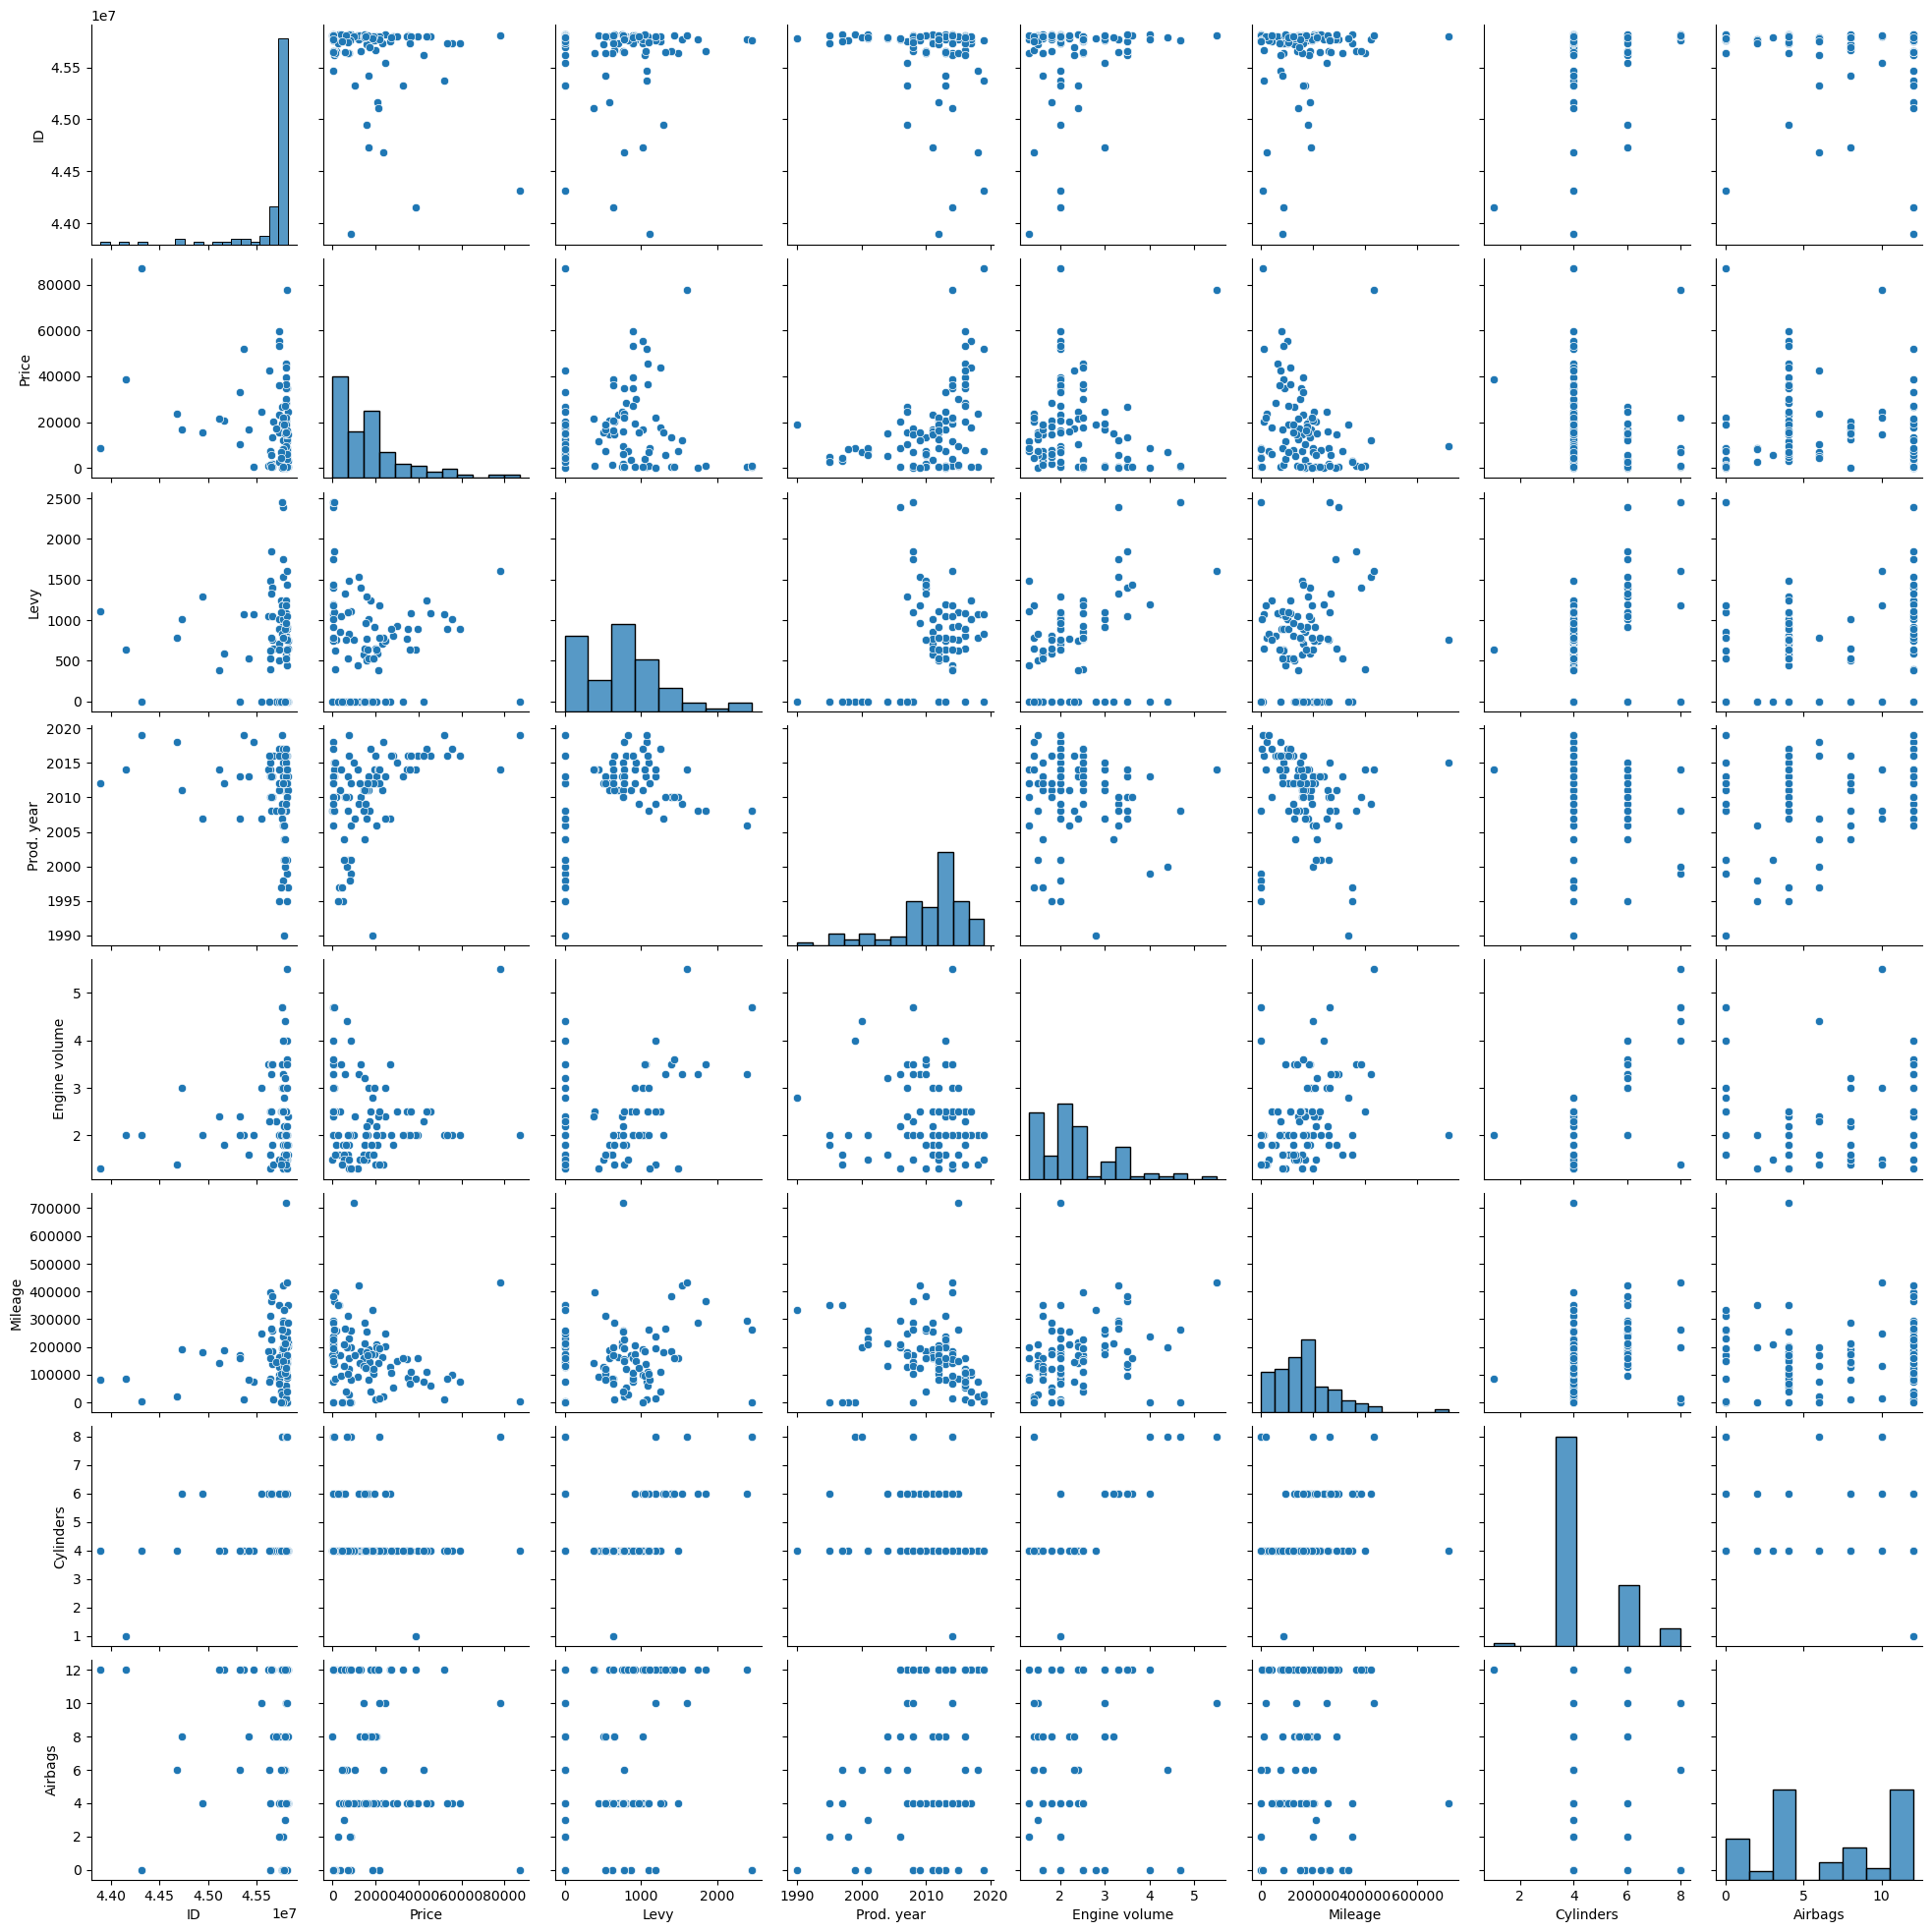

In [57]:
sns.pairplot(data[:100])

<Axes: ylabel='Price'>

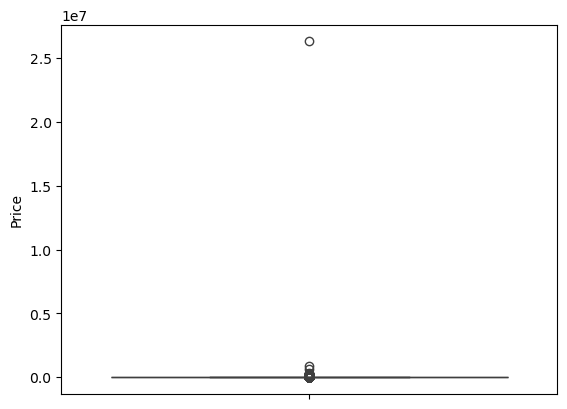

In [58]:
sns.boxplot(data['Price'])

In [59]:
data[data["Price"] > 5e5]

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
1225,45795524,627220,0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3,0,8.0,Tiptronic,4x4,Left wheel,Black,12
8541,45761204,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4.0,2531,8.0,Tiptronic,4x4,Left wheel,Black,0
16983,45812886,26307500,0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999,4.0,Manual,Front,Left wheel,Blue,0


<Axes: ylabel='Levy'>

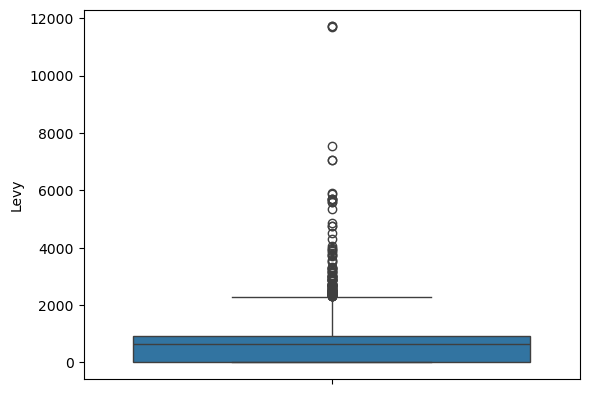

In [60]:
sns.boxplot(data['Levy'])

In [ ]:
# Outliers removal 
def clean_outliers(df, cols):
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

data = clean_outliers(data, ['Price','Mileage','Levy'])

data.shape

(17084, 17)

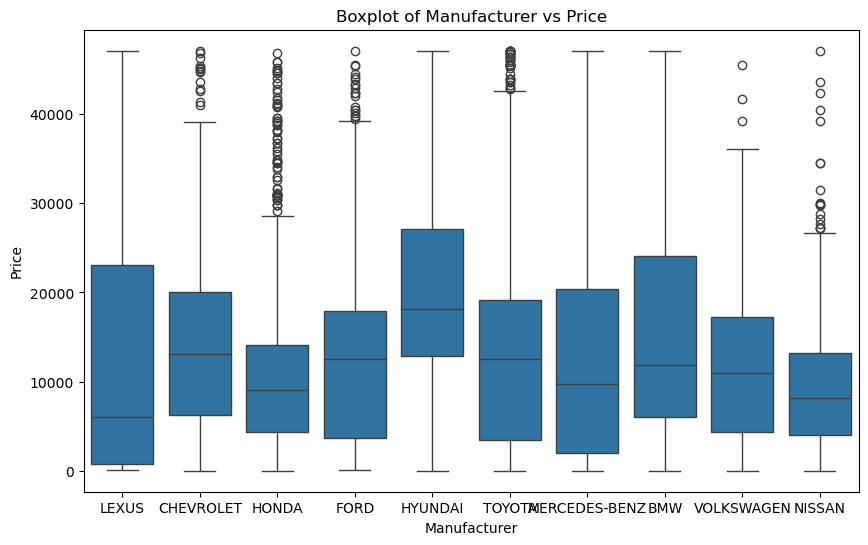

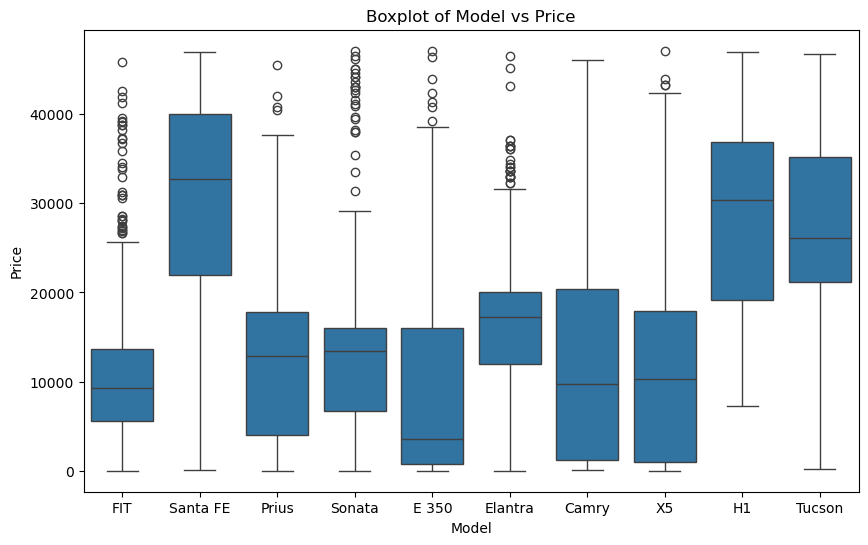

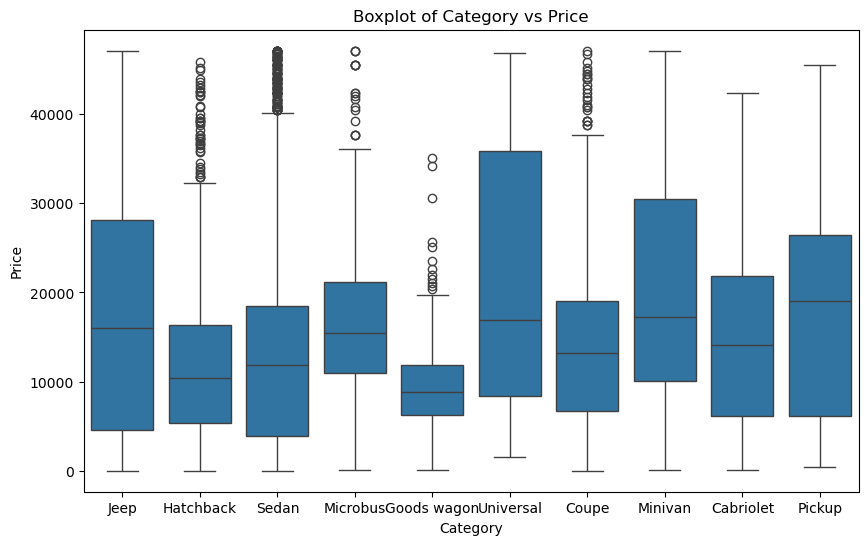

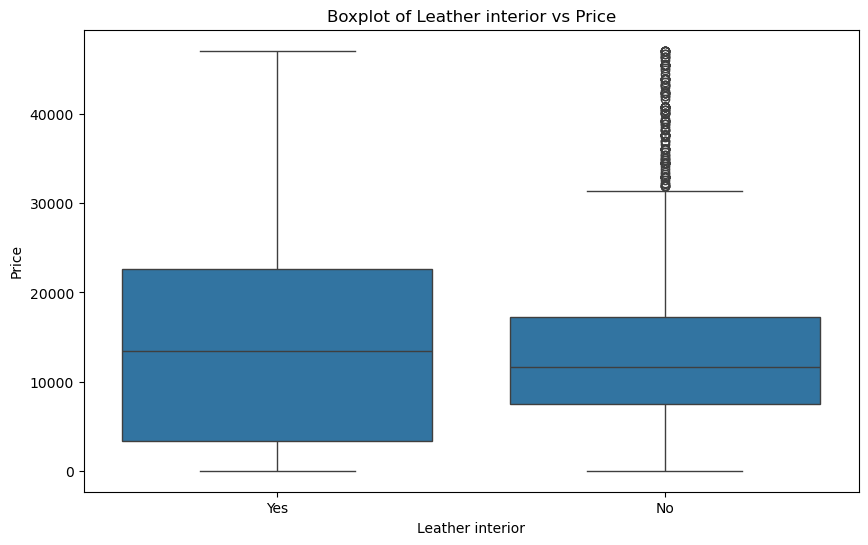

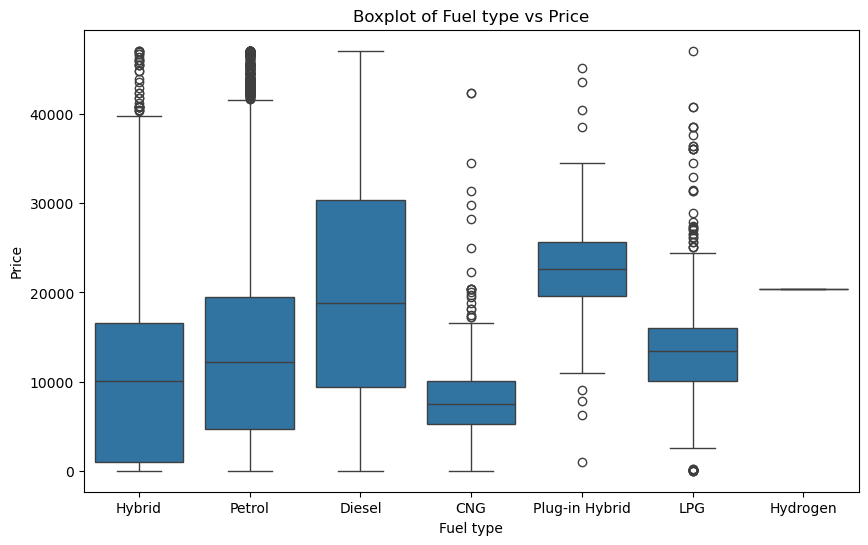

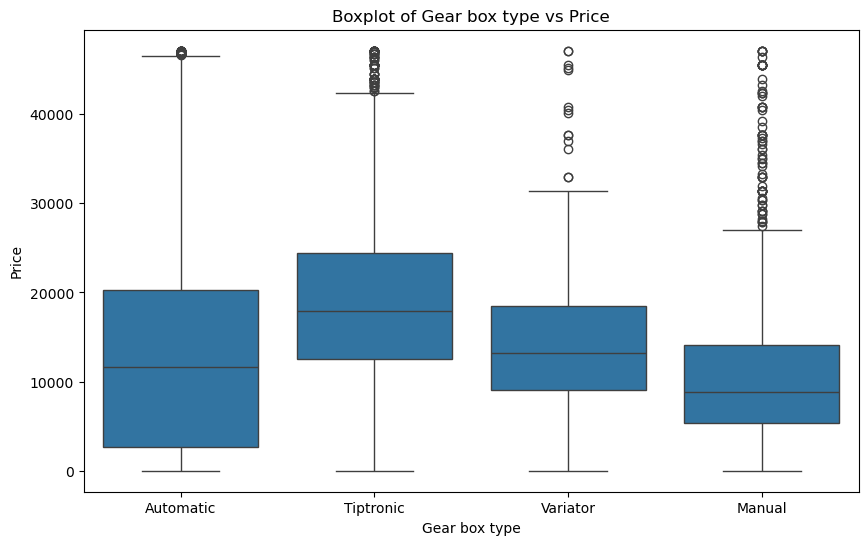

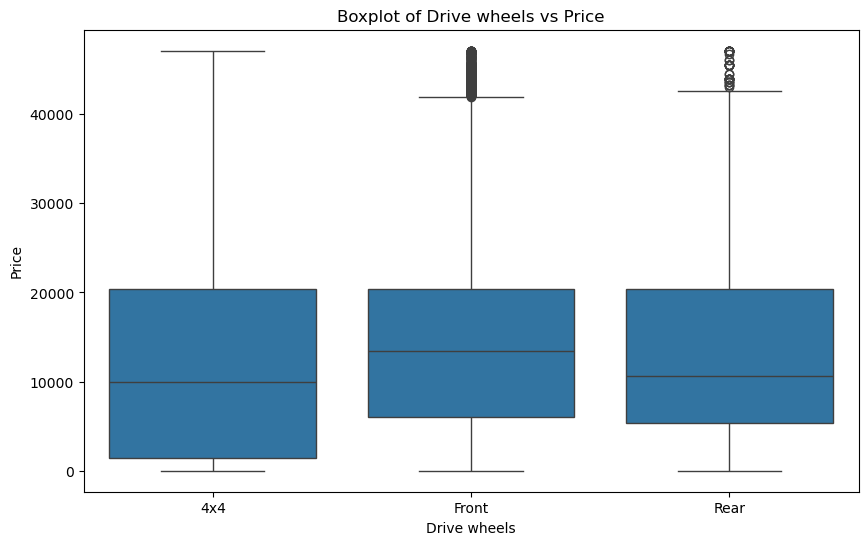

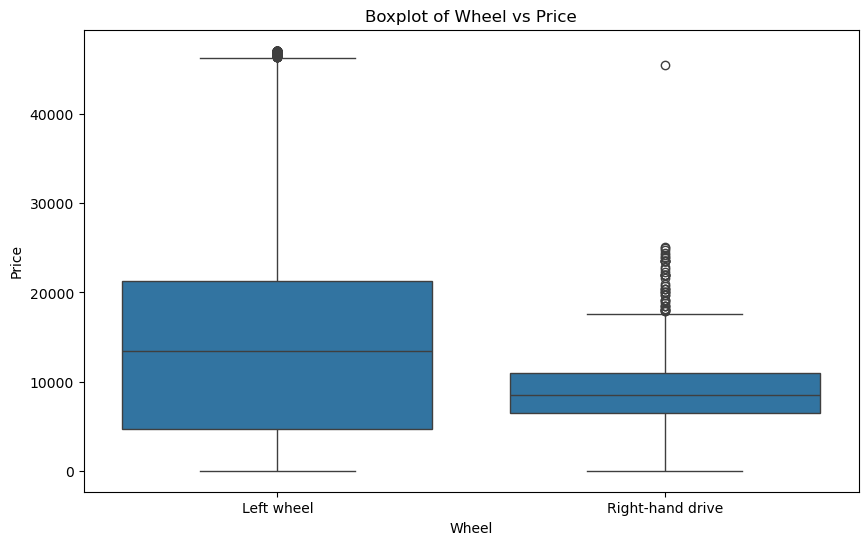

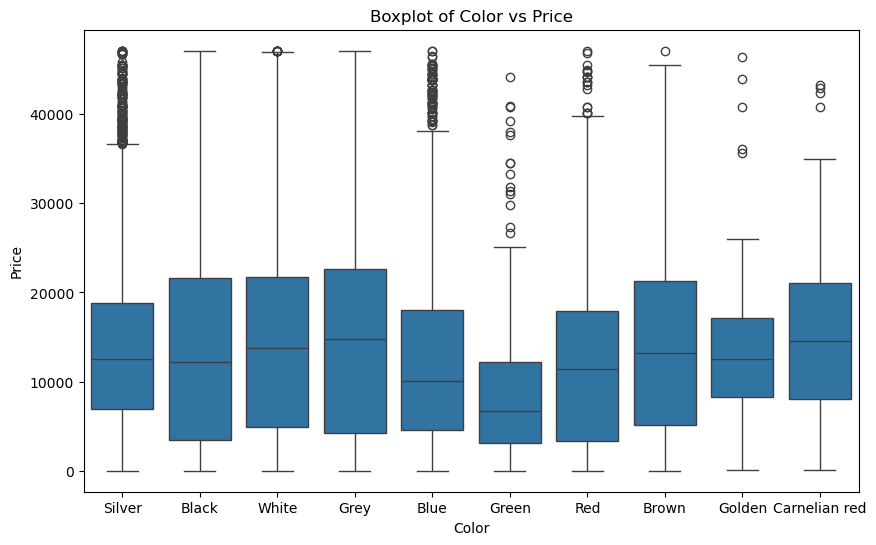

In [68]:
for col in data.select_dtypes('object'):
    top_categories = data[col].value_counts().index[:10]
    filtered_df = data[data[col].isin(top_categories)]

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=filtered_df[col], y=filtered_df['Price'])
    plt.title(f'Boxplot of {col} vs Price')


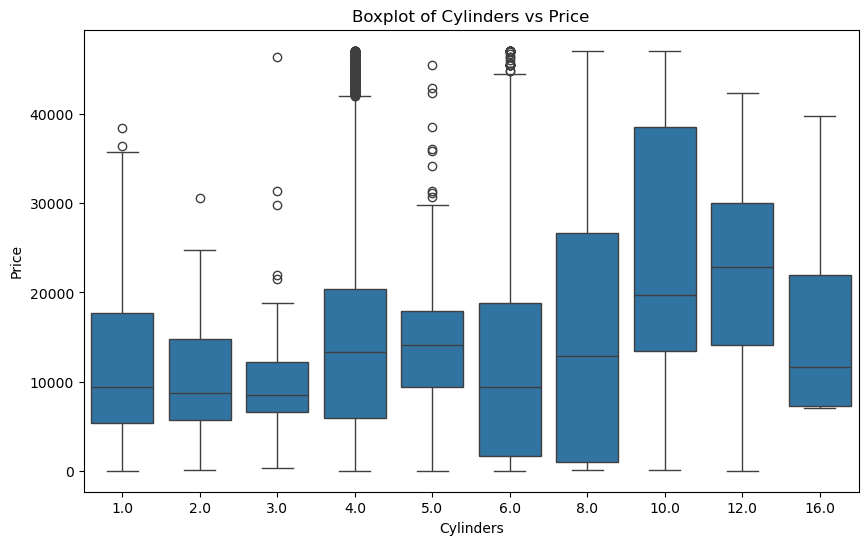

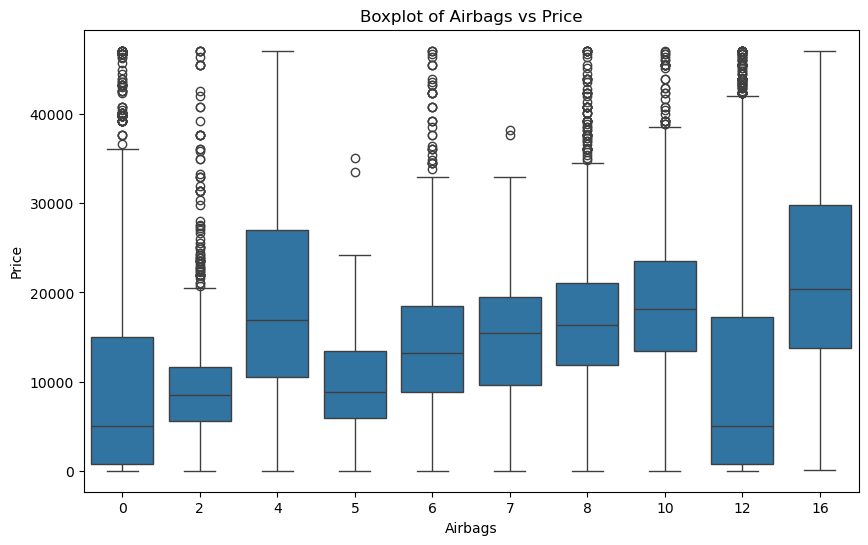

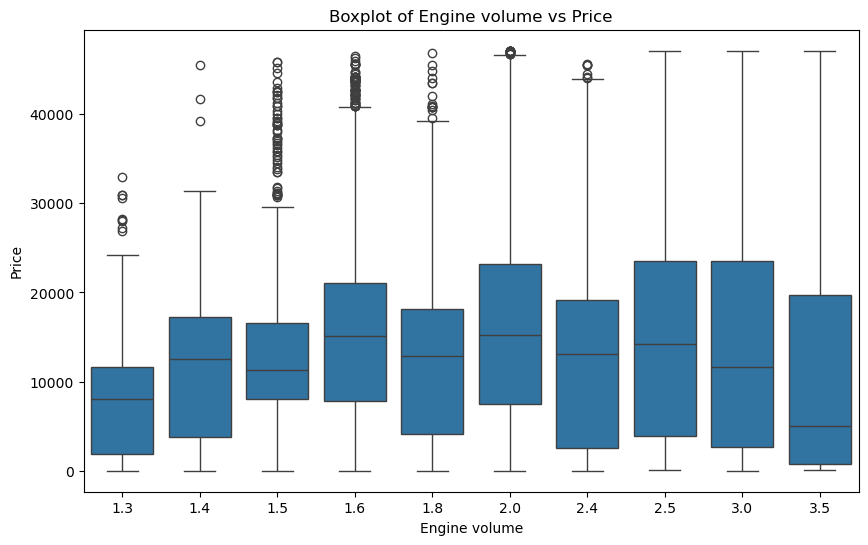

In [69]:
for col in ["Cylinders","Airbags","Engine volume"]:
    top_categories = data[col].value_counts().index[:10]
    filtered_df = data[data[col].isin(top_categories)]

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=filtered_df[col], y=filtered_df['Price'])
    plt.title(f'Boxplot of {col} vs Price')